# Has Dota 2 esports finished growing?

**Purpose:** the Dota 2 counterpart to `notebooks/cs_growth_trajectory.ipynb`
and `docs/counter_strike_lifecycle_brief.md` — same question, same design
(brief §5a's four independently-tracked dimensions, shown before any
composite view), applied to a different title so the two can be compared
directly. Built 2026-09-09, after checking Dota 2's data readiness
against everything the CS notebook depends on (`docs/
counter_strike_lifecycle_brief.md` §11) rather than assuming parity.

**Two real differences from the CS build, stated here rather than
discovered mid-chart**:
1. Dota 2's tier-1/2 prize-pool coverage is **31%**, vs. CS's 85% —
   confirmed live: most gaps are genuine qualifier sub-brackets with no
   separate prize allocation (same as CS), but a real parsing gap sits
   underneath that too — `collectors/liquipedia.py`'s `parse_infobox()`
   doesn't read `{{TeamPrizePool}}`, a separate per-team-payout template
   an entire real series (BLAST SLAM, editions 4-8+) uses instead of the
   flat field. Every prize-pool figure below is a **floor, not a
   complete total** — likely more so for Dota 2 than it was for CS.
2. Dota 2 has no single engine-relaunch event comparable to CS2's August
   2023 transition, so no equivalent structural-break marker is drawn on
   these charts — not because nothing ever changed for Dota 2, but
   because nothing in this dataset's window is verified to be that kind
   of single, sharp discontinuity. Don't read the absence of a dashed
   line as "nothing happened."

## 0. A real bug, found and fixed while building this notebook

Dota 2's 2013 flagship event (`get_championship_windows()`) initially
came back as a **120,000,000** prize pool — implausible (the real 2013
International's prize pool was a few million dollars). Checked directly:
that number is in **Korean Won** (`currency='krw'`), not USD, and
`analysis/metrics.py:get_championship_windows()` had no currency filter
at all — it picked the numerically-largest raw `prize_pool` regardless of
currency. Checked how widely this affected the whole project, not just
this one row: **95 of 291 championship windows across the full 23-title
dataset (32.6%) had a non-USD currency, including every single
`league_of_legends` year 2012-2025** (LCK's KRW figures beating Worlds'
USD ones every time). Fixed in `analysis/metrics.py` (restricted to
`currency='USD'` or `currency IS NULL`), covered by three new tests in
`tests/test_metrics.py`, and every ad-hoc SQL query in this notebook that
touches `prize_pool` carries the same filter. **Counter-Strike does not
appear anywhere in the affected list** — its own already-reported
figures in `notebooks/cs_growth_trajectory.ipynb` and `docs/
counter_strike_lifecycle_brief.md` are unaffected and were re-verified,
not just assumed clean.

In [1]:
# Imports and repo path setup — identical to cs_growth_trajectory.ipynb.
import csv
import sys
from collections import defaultdict
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import httpx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import ruptures as rpt
from scipy.optimize import curve_fit

from etl.db import get_connection
from analysis.metrics import get_championship_windows, get_concentration

conn = get_connection()
plt.rcParams["figure.dpi"] = 110
TIER_VALUES = ("1", "2")  # Dota2 uses plain numeric tiers only -- no S-Tier/A-Tier label form (checked live, unlike CS)

## 1. Data coverage — stated explicitly before anything else

In [2]:
coverage = pd.read_sql_query(
    "SELECT substr(year_month,1,4) AS yr, count(*) AS months "
    "FROM monthly_category_history WHERE title_id='dota2' GROUP BY yr ORDER BY yr",
    conn,
)
print("Dota 2 category-wide Twitch hours — months of coverage per year:")
print(coverage.to_string(index=False))

Dota 2 category-wide Twitch hours — months of coverage per year:
  yr  months
2016      12
2017      12
2018      12
2019      12
2020      12
2021      12
2022      12
2023      12
2024       9
2026       2


**Same Kaggle-dataset-wide gap as CS**: the import ends 2024-09, and
`own_collector` only starts 2026-08 — no category-wide Twitch coverage
Oct 2024 – Jul 2026, confirmed dataset-wide (not title-specific) when
building the CS notebook. Every chart below marks this the same way.

In [3]:
def category_hours_by_year(title_id: str) -> pd.DataFrame:
    df = pd.read_sql_query(
        "SELECT substr(year_month,1,4) AS yr, sum(hours_watched) AS hours, count(*) AS months "
        "FROM monthly_category_history WHERE title_id=? GROUP BY yr ORDER BY yr",
        conn, params=(title_id,),
    )
    df["yr"] = df["yr"].astype(int)
    df["complete"] = df["months"] == 12
    return df

dota2_hours = category_hours_by_year("dota2")
cs_hours = category_hours_by_year("counter_strike")
valorant_hours = category_hours_by_year("valorant")

## 2. Audience attention — category-wide Twitch hours

Dota 2 against two baselines: Counter-Strike (comparable vintage — both
"Classic phase" titles per `docs/esports_gauses_law_brief.md`'s own era
framework) and VALORANT (younger, still growing — a positive control).

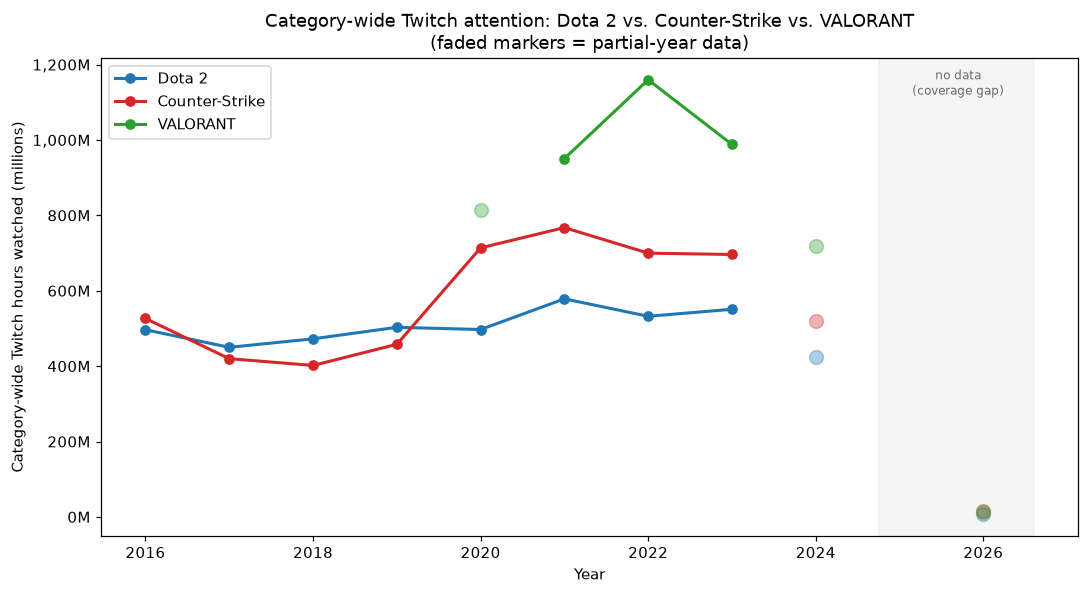

  yr        hours  complete
2016 4.965860e+08      True
2017 4.498795e+08      True
2018 4.724148e+08      True
2019 5.030226e+08      True
2020 4.971513e+08      True
2021 5.784843e+08      True
2022 5.322532e+08      True
2023 5.508394e+08      True
2024 4.231366e+08     False
2026 7.817311e+06     False


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for df, label, color in [
    (dota2_hours, "Dota 2", "#1f77b4"),
    (cs_hours, "Counter-Strike", "#d62728"),
    (valorant_hours, "VALORANT", "#2ca02c"),
]:
    complete = df[df["complete"]]
    partial = df[~df["complete"]]
    ax.plot(complete["yr"], complete["hours"] / 1e6, "o-", color=color, label=label, linewidth=2)
    if len(partial):
        ax.plot(partial["yr"], partial["hours"] / 1e6, "o", color=color, alpha=0.35, markersize=9)

ax.axvspan(2024.75, 2026.6, alpha=0.08, color="gray")
ax.text(2025.7, ax.get_ylim()[1] * 0.92, "no data\n(coverage gap)", ha="center", fontsize=8, color="dimgray")
ax.set_xlabel("Year")
ax.set_ylabel("Category-wide Twitch hours watched (millions)")
ax.set_title("Category-wide Twitch attention: Dota 2 vs. Counter-Strike vs. VALORANT\n(faded markers = partial-year data)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}M"))
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig1_attention.png", dpi=110)
plt.show()

print(dota2_hours[["yr", "hours", "complete"]].to_string(index=False))

**Read**: a much smoother curve than CS's — no sharp COVID spike-and-crash.
Dota 2 rises gently 2016-2019 (450-503M), holds roughly flat through the
COVID year (2020, 497M — CS jumped ~56% that year, Dota 2 barely moved),
then peaks in 2021 (578M) and settles at 2023's 551M, only 4.8% below that
peak — the smallest peak-to-last-complete-year drawdown of any title
looked at in this pair of notebooks. Whatever CS's attention volatility
reflects (tournament calendar, COVID-era shifts, the CS2 transition),
Dota 2 doesn't show the same pattern on this metric.

## 3. Competitive infrastructure — tournament count, teams, regions

Dota 2's tier-1/2 history runs 2005–2028 — no generational-continuity
question at all (unlike CS, Dota 2 never changed core engines), and
already the longest series of any tracked title in this project.

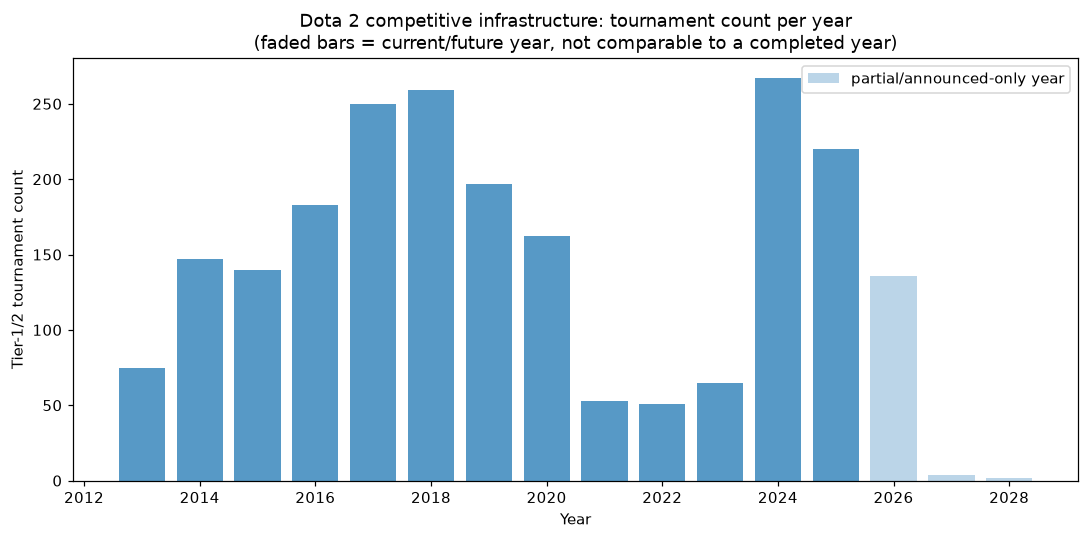

  yr  n_tournaments  n_regions  avg_teams  complete
2013             75          3  15.675676      True
2014            147          4  18.474820      True
2015            140          3  53.131579      True
2016            183          5 111.485549      True
2017            250          5  74.918367      True
2018            259          5  46.352941      True
2019            197          3  50.020513      True
2020            162          3  15.576923      True
2021             53          2  12.301887      True
2022             51          3  10.058824      True
2023             65          4  19.693548      True
2024            267          3  19.698113      True
2025            220          3  19.509091      True
2026            136          2  20.691176     False
2027              4          2  20.000000     False
2028              2          1  16.000000     False


In [5]:
infra = pd.read_sql_query(
    # sum(prize_pool) is filtered to USD-or-unlabeled via a CASE, not a
    # WHERE clause -- a WHERE clause would also wrongly exclude non-USD
    # rows from n_tournaments/n_regions/avg_teams, which are currency-
    # independent and must count every tier-1/2 event regardless of
    # whether its prize pool is even known. Real bug found 2026-09-09
    # (see analysis/metrics.py:get_championship_windows's docstring) --
    # raw prize_pool numbers mix currencies with no normalization.
    "SELECT substr(start_date,1,4) AS yr, count(*) AS n_tournaments, "
    "count(distinct region) AS n_regions, avg(team_number) AS avg_teams, "
    "sum(CASE WHEN currency='USD' OR currency IS NULL THEN prize_pool END) AS prize_pool_nominal "
    "FROM tournaments WHERE title_id='dota2' AND tier IN ('1','2') "
    "AND start_date IS NOT NULL AND start_date != '' GROUP BY yr ORDER BY yr",
    conn,
)
infra = infra[infra["yr"].str.match(r"^\d{4}$")].copy()
infra["yr"] = infra["yr"].astype(int)
COMPLETE_THROUGH = 2025  # 2026 partial as of this build; 2027-2028 announced-only
infra["complete"] = infra["yr"] <= COMPLETE_THROUGH

infra_complete = infra[(infra["complete"]) & (infra["yr"] >= 2013)]
partial = infra[~infra["complete"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(infra_complete["yr"], infra_complete["n_tournaments"], color="#1f77b4", alpha=0.75)
ax.bar(partial["yr"], partial["n_tournaments"], color="#1f77b4", alpha=0.3, label="partial/announced-only year")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 tournament count")
ax.set_title("Dota 2 competitive infrastructure: tournament count per year\n(faded bars = current/future year, not comparable to a completed year)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig2_infra.png", dpi=110)
plt.show()

print(infra[infra["yr"] >= 2013][["yr", "n_tournaments", "n_regions", "avg_teams", "complete"]].to_string(index=False))

## 4. Real (CPI-deflated) prize pool — read with the §1 coverage caveat in mind

Reuses `data/reference/cpi_deflator.csv` as-is (general-purpose, not
CS-specific). **Every figure here is a floor** — the `{{TeamPrizePool}}`
parsing gap (§1) means real totals are understated, likely by more than
for CS given the lower coverage rate.

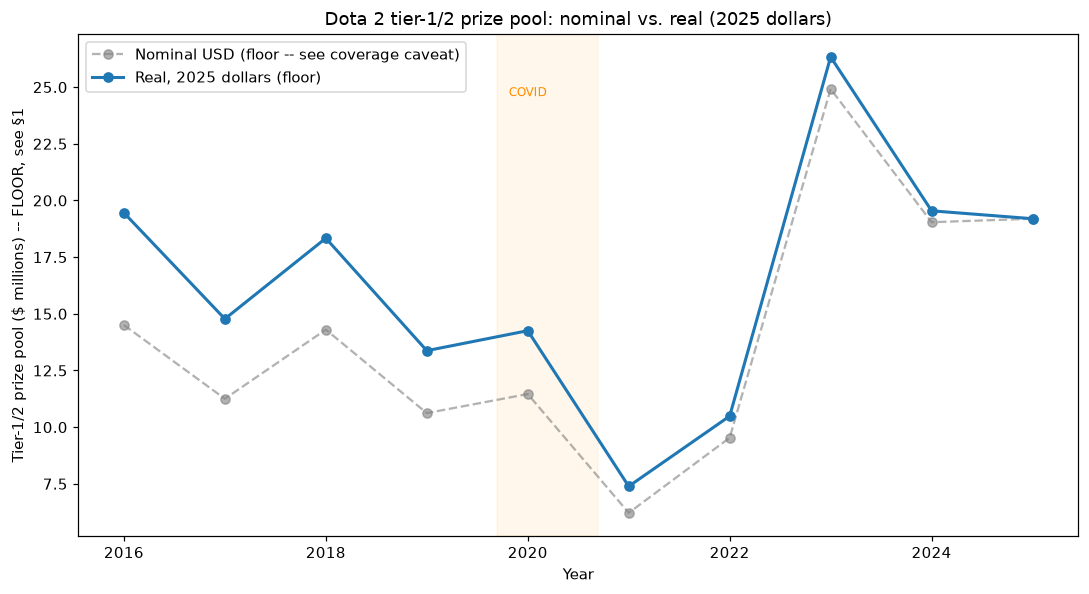

  yr  prize_pool_nominal  prize_pool_real_2025
2016          14504032.0            19455709.0
2017          11251873.0            14775960.0
2018          14302000.0            18335164.0
2019          10620000.0            13373766.0
2020          11460000.0            14255094.0
2021           6220000.0             7389982.0
2022           9532500.0            10487656.0
2023          24919500.0            26329944.0
2024          19039998.0            19542654.0
2025          19195000.0            19195000.0


In [6]:
deflator = {}
with open(REPO_ROOT / "data" / "reference" / "cpi_deflator.csv") as f:
    for row in csv.DictReader(f):
        deflator[int(row["year"])] = float(row["deflator_to_2025"])

infra["prize_pool_real_2025"] = infra.apply(
    lambda r: r["prize_pool_nominal"] * deflator.get(r["yr"], np.nan) if r["prize_pool_nominal"] else np.nan,
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = infra[(infra["yr"] >= 2016) & (infra["yr"] <= COMPLETE_THROUGH)]
ax.plot(plot_df["yr"], plot_df["prize_pool_nominal"] / 1e6, "o--", color="gray", alpha=0.6, label="Nominal USD (floor -- see coverage caveat)")
ax.plot(plot_df["yr"], plot_df["prize_pool_real_2025"] / 1e6, "o-", color="#1f77b4", linewidth=2, label="Real, 2025 dollars (floor)")
ax.axvspan(2019.7, 2020.7, alpha=0.08, color="orange")
ax.text(2020, ax.get_ylim()[1] * 0.9, "COVID", ha="center", fontsize=8, color="darkorange")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 prize pool ($ millions) -- FLOOR, see §1")
ax.set_title("Dota 2 tier-1/2 prize pool: nominal vs. real (2025 dollars)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig3_prizepool.png", dpi=110)
plt.show()

print(plot_df[["yr", "prize_pool_nominal", "prize_pool_real_2025"]].round(0).to_string(index=False))

## 5. Supply vs. demand — hours watched vs. tournament supply

Same three-way diagnostic as the CS brief §5c: rising ratio = new
audience; flat/keeping pace = supply absorbed without dilution; falling
= the actual saturation signal. Restricted to years both series have
complete data.

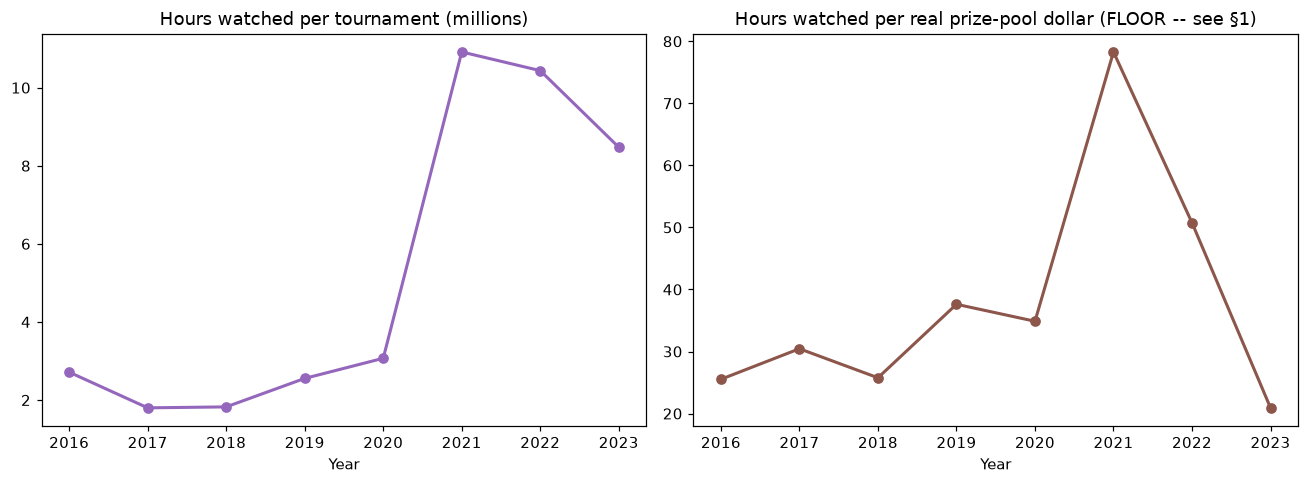

  yr       hours  n_tournaments  hours_per_tournament  hours_per_real_dollar
2016 496585969.0            183            2713584.53                  25.52
2017 449879503.0            250            1799518.01                  30.45
2018 472414819.0            259            1823995.44                  25.77
2019 503022570.0            197            2553414.06                  37.61
2020 497151335.0            162            3068835.40                  34.88
2021 578484298.0             53           10914798.08                  78.28
2022 532253215.0             51           10436337.55                  50.75
2023 550839394.0             65            8474452.22                  20.92


In [7]:
merged = dota2_hours[dota2_hours["complete"]].merge(
    infra[["yr", "n_tournaments", "prize_pool_real_2025"]], on="yr", how="inner"
)
merged["hours_per_tournament"] = merged["hours"] / merged["n_tournaments"]
merged["hours_per_real_dollar"] = merged["hours"] / merged["prize_pool_real_2025"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(merged["yr"], merged["hours_per_tournament"] / 1e6, "o-", color="#9467bd", linewidth=2)
axes[0].set_title("Hours watched per tournament (millions)")
axes[0].set_xlabel("Year")
axes[1].plot(merged["yr"], merged["hours_per_real_dollar"], "o-", color="#8c564b", linewidth=2)
axes[1].set_title("Hours watched per real prize-pool dollar (FLOOR -- see §1)")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig4_intensity.png", dpi=110)
plt.show()

print(merged[["yr", "hours", "n_tournaments", "hours_per_tournament", "hours_per_real_dollar"]].round(2).to_string(index=False))

## 6. Market concentration — event-level

`analysis/metrics.py:get_concentration()`, applied within Dota 2's own
full tier-1/2 slate per year — same tool the Gause's Law brief's H3
applies across titles, here applied within one title.

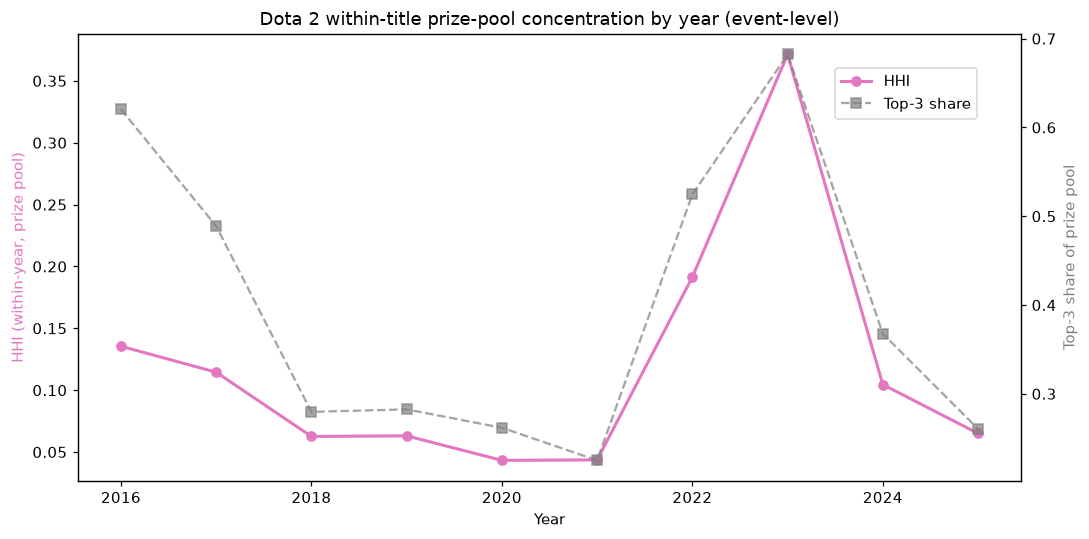

  yr  n    hhi  top3_share
2016 41 0.1355      0.6205
2017 39 0.1145      0.4888
2018 29 0.0626      0.2797
2019 27 0.0631      0.2825
2020 63 0.0433      0.2618
2021 29 0.0436      0.2251
2022 33 0.1914      0.5245
2023 35 0.3714      0.6822
2024 30 0.1045      0.3676
2025 22 0.0650      0.2605


In [8]:
conc_rows = []
for yr in range(2016, 2026):
    values = [r[0] for r in conn.execute(
        "SELECT prize_pool FROM tournaments WHERE title_id='dota2' AND tier IN ('1','2') "
        "AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0 "
        "AND (currency='USD' OR currency IS NULL)",
        (f"{yr}%",),
    ).fetchall()]
    if not values:
        continue
    result = get_concentration(values)
    conc_rows.append({"yr": yr, "n": len(values), "hhi": result["hhi"], "top3_share": result["top3_share"]})

conc = pd.DataFrame(conc_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(conc["yr"], conc["hhi"], "o-", color="#e377c2", linewidth=2, label="HHI")
ax2 = ax.twinx()
ax2.plot(conc["yr"], conc["top3_share"], "s--", color="#7f7f7f", linewidth=1.5, alpha=0.7, label="Top-3 share")
ax.set_xlabel("Year")
ax.set_ylabel("HHI (within-year, prize pool)", color="#e377c2")
ax2.set_ylabel("Top-3 share of prize pool", color="#7f7f7f")
ax.set_title("Dota 2 within-title prize-pool concentration by year (event-level)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig5_concentration.png", dpi=110)
plt.show()

print(conc.round(4).to_string(index=False))

## 7. The flagship event itself — `get_championship_windows()`

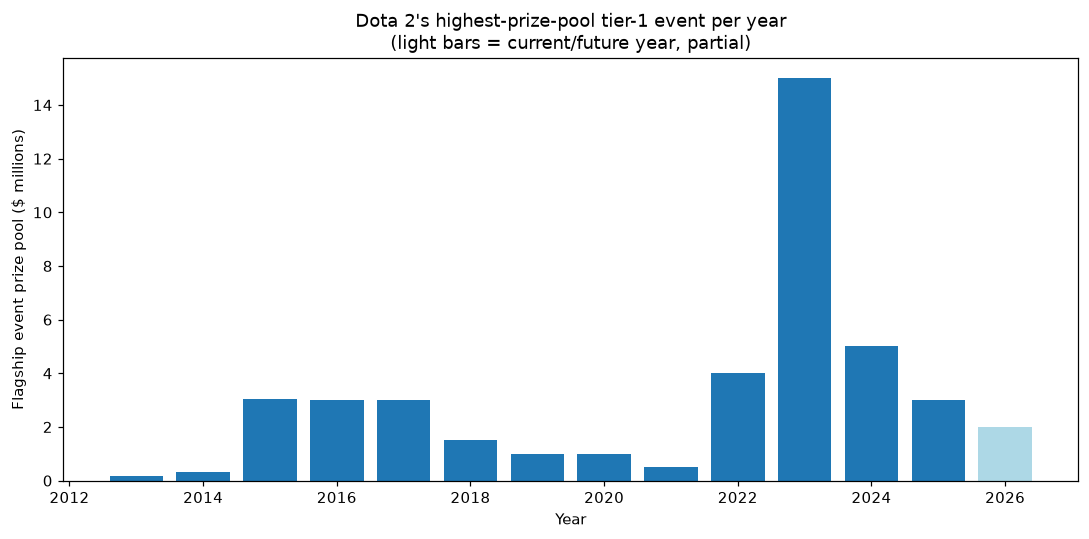

 year  prize_pool
 2013    163050.0
 2014    311655.0
 2015   3057519.0
 2016   3000000.0
 2017   3000000.0
 2018   1500000.0
 2019   1000000.0
 2020   1000000.0
 2021    500000.0
 2022   4000000.0
 2023  15000000.0
 2024   5000000.0
 2025   3000000.0
 2026   2000000.0


In [9]:
windows = get_championship_windows(conn, "dota2")
champ = pd.DataFrame(windows)
champ = champ[(champ["year"] >= 2013) & (champ["year"] <= 2026)].sort_values("year")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1f77b4" if y <= COMPLETE_THROUGH else "lightblue" for y in champ["year"]]
ax.bar(champ["year"], champ["prize_pool"] / 1e6, color=colors)
ax.set_xlabel("Year")
ax.set_ylabel("Flagship event prize pool ($ millions)")
ax.set_title("Dota 2's highest-prize-pool tier-1 event per year\n(light bars = current/future year, partial)")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig6_flagship.png", dpi=110)
plt.show()

print(champ[["year", "prize_pool"]].to_string(index=False))

**Note**: Dota 2's flagship event (The International) historically drew
much of its prize pool from crowdfunded "Battle Pass" compendium sales, a
funding mechanism CS's own Majors don't use — worth keeping in mind when
comparing absolute flagship-prize-pool levels between the two titles,
not just their year-over-year shape.

## 8. Organizer-level consolidation check

Same technique as the CS brief's §13 finding (event-level concentration
can look completely different from organizer-level concentration) — run
here without assuming the CS finding transfers.

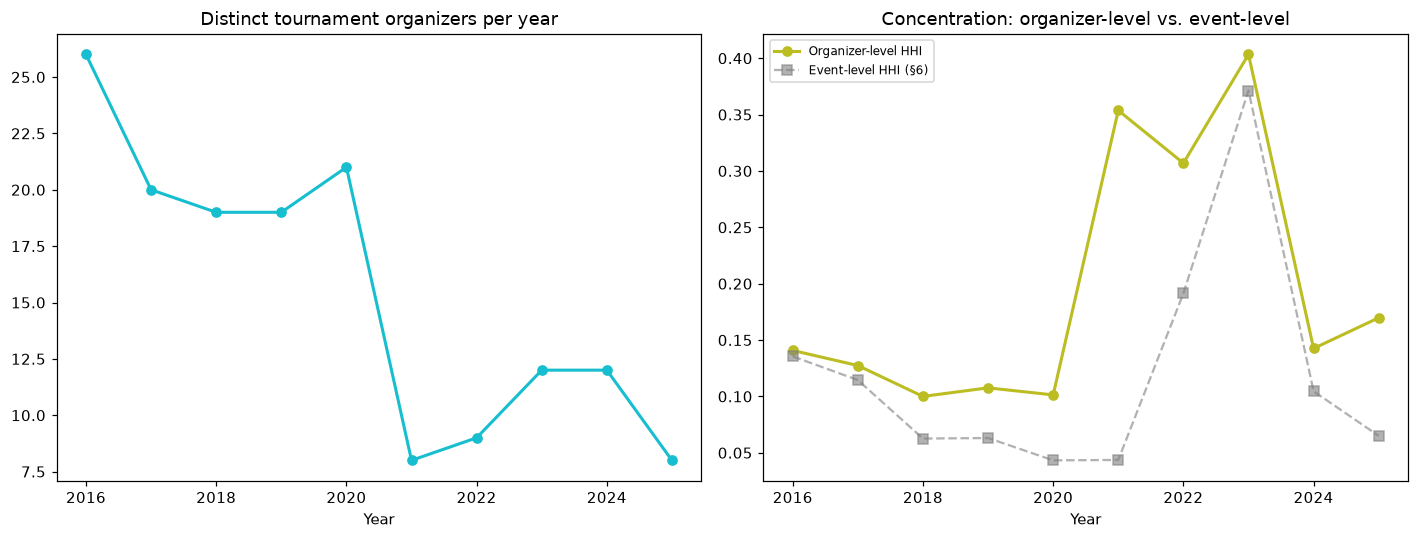

  yr  n_orgs    hhi  top3_share
2016      26 0.1408      0.6205
2017      20 0.1274      0.5110
2018      19 0.1000      0.4350
2019      19 0.1076      0.4473
2020      21 0.1013      0.4110
2021       8 0.3537      0.7854
2022       9 0.3069      0.8563
2023      12 0.4034      0.8704
2024      12 0.1425      0.5252
2025       8 0.1697      0.5897


In [10]:
def organizer_hhi_by_year(title_id: str, tiers: tuple) -> pd.DataFrame:
    rows_out = []
    for yr in range(2016, 2026):
        placeholders = ",".join("?" for _ in tiers)
        rows = conn.execute(
            f"SELECT liquipedia_page, prize_pool FROM tournaments WHERE title_id=? "
            f"AND tier IN ({placeholders}) AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0 "
            f"AND (currency='USD' OR currency IS NULL)",
            (title_id, *tiers, f"{yr}%"),
        ).fetchall()
        org_totals = defaultdict(float)
        for page, pool in rows:
            org_totals[page.split("/")[0]] += pool
        result = get_concentration(list(org_totals.values())) if org_totals else {"hhi": None, "top3_share": None}
        rows_out.append({"yr": yr, "n_orgs": len(org_totals), "hhi": result["hhi"], "top3_share": result["top3_share"]})
    return pd.DataFrame(rows_out)

org_conc = organizer_hhi_by_year("dota2", TIER_VALUES)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(org_conc["yr"], org_conc["n_orgs"], "o-", color="#17becf", linewidth=2)
axes[0].set_title("Distinct tournament organizers per year")
axes[0].set_xlabel("Year")

axes[1].plot(org_conc["yr"], org_conc["hhi"], "o-", color="#bcbd22", linewidth=2, label="Organizer-level HHI")
axes[1].plot(conc["yr"], conc["hhi"], "s--", color="#7f7f7f", linewidth=1.5, alpha=0.6, label="Event-level HHI (§6)")
axes[1].set_title("Concentration: organizer-level vs. event-level")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig7_organizer.png", dpi=110)
plt.show()

print(org_conc.round(4).to_string(index=False))

## 9. Robustness check — the EWC/Gamers8/Gamers Without Borders/Riyadh Masters lineage

**A fourth brand found while building this section, not in the original
CS-derived list**: `get_championship_windows()`'s currency-bug fix (§0,
`analysis/metrics.py`) surfaced `Riyadh Masters` as Dota 2's actual
flagship event in 2022-2024 — $4M (2022), **$15M (2023)**, $5M (2024).
Same Saudi state-backed pattern as Esports World Cup/Gamers8/Gamers
Without Borders, just a different specific brand this project's
CS-derived search list didn't happen to include. Checked CS for the same
gap directly: no "Riyadh"-branded CS event exists, so CS's own EWC-lineage
check stands as already reported. This is a real methodology lesson, not
just a Dota2 footnote: name-pattern lineage detection is fragile and can
miss real instances under different branding — worth remembering before
treating any such list as exhaustive again.

EWC-lineage Dota 2 tournaments WITH a recorded USD prize pool (most sub-brackets have none):
       liquipedia_page start_date  prize_pool
   Riyadh Masters/2022 2022-07-20   4000000.0
   Riyadh Masters/2023 2023-07-19  15000000.0
   Riyadh Masters/2024 2024-07-04   5000000.0
Esports World Cup/2025 2025-07-08   3000000.0
Esports World Cup/2026 2026-07-07   2000000.0


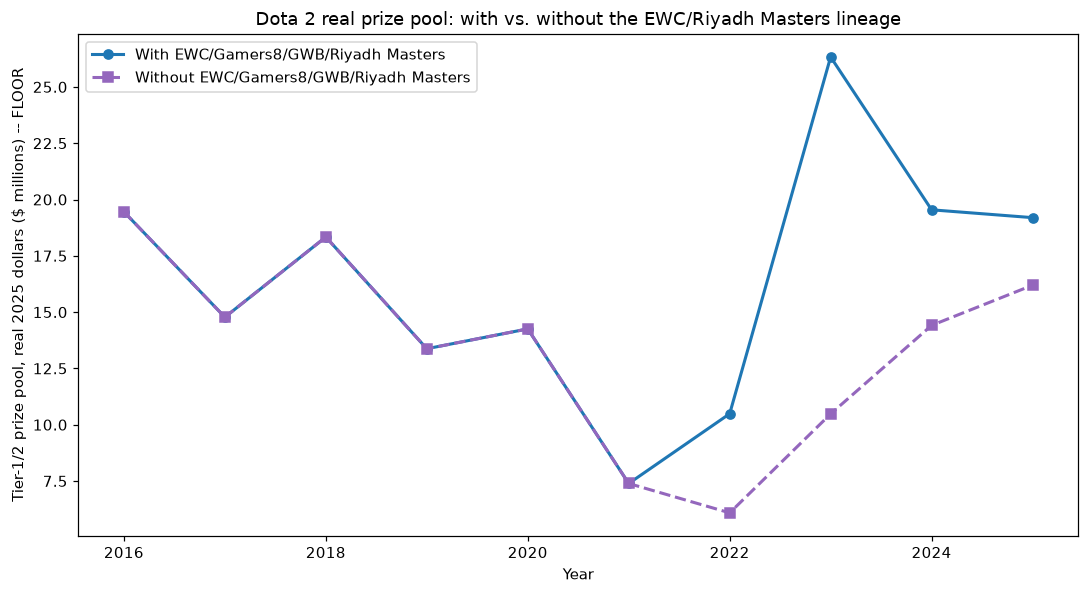

  yr  prize_pool_real_2025_with  prize_pool_real_2025_without    removed
2016                 19455709.0                    19455709.0        0.0
2017                 14775960.0                    14775960.0        0.0
2018                 18335164.0                    18335164.0        0.0
2019                 13373766.0                    13373766.0        0.0
2020                 14255094.0                    14255094.0        0.0
2021                  7389982.0                     7389982.0        0.0
2022                 10487656.0                     6086856.0  4000000.0
2023                 26329944.0                    10480944.0 15000000.0
2024                 19542654.0                    14410654.0  5000000.0
2025                 19195000.0                    16195000.0  3000000.0


In [11]:
EWC_FAMILY = ("%Esports World Cup%", "%Gamers8%", "%Gamers Without Borders%", "%Riyadh Masters%")
excl_clause = " AND ".join(f"liquipedia_page NOT LIKE '{p}'" for p in EWC_FAMILY)

ewc_rows = pd.read_sql_query(
    "SELECT liquipedia_page, start_date, prize_pool FROM tournaments WHERE title_id='dota2' "
    "AND (liquipedia_page LIKE ? OR liquipedia_page LIKE ? OR liquipedia_page LIKE ? OR liquipedia_page LIKE ?) "
    "AND prize_pool IS NOT NULL AND (currency='USD' OR currency IS NULL) ORDER BY start_date",
    conn, params=EWC_FAMILY,
)
print("EWC-lineage Dota 2 tournaments WITH a recorded USD prize pool (most sub-brackets have none):")
print(ewc_rows.to_string(index=False))

def prize_pool_by_year(exclude_ewc: bool) -> pd.DataFrame:
    where_extra = f"AND {excl_clause}" if exclude_ewc else ""
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(prize_pool) AS prize_pool_nominal "
        f"FROM tournaments WHERE title_id='dota2' AND tier IN ('1','2') "
        f"AND start_date IS NOT NULL AND start_date != '' AND prize_pool IS NOT NULL "
        f"AND (currency='USD' OR currency IS NULL) {where_extra} "
        f"GROUP BY yr ORDER BY yr", conn,
    )
    df = df[df["yr"].str.match(r"^\d{4}$")].copy()
    df["yr"] = df["yr"].astype(int)
    df["prize_pool_real_2025"] = df.apply(lambda r: r["prize_pool_nominal"] * deflator.get(r["yr"], np.nan), axis=1)
    return df

with_ewc = prize_pool_by_year(exclude_ewc=False)
without_ewc = prize_pool_by_year(exclude_ewc=True)

plot_with = with_ewc[(with_ewc["yr"] >= 2016) & (with_ewc["yr"] <= COMPLETE_THROUGH)]
plot_without = without_ewc[(without_ewc["yr"] >= 2016) & (without_ewc["yr"] <= COMPLETE_THROUGH)]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(plot_with["yr"], plot_with["prize_pool_real_2025"] / 1e6, "o-", color="#1f77b4", linewidth=2, label="With EWC/Gamers8/GWB/Riyadh Masters")
ax.plot(plot_without["yr"], plot_without["prize_pool_real_2025"] / 1e6, "s--", color="#9467bd", linewidth=2, label="Without EWC/Gamers8/GWB/Riyadh Masters")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 prize pool, real 2025 dollars ($ millions) -- FLOOR")
ax.set_title("Dota 2 real prize pool: with vs. without the EWC/Riyadh Masters lineage")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig8_ewc_control.png", dpi=110)
plt.show()

merged_check = plot_with.merge(plot_without, on="yr", suffixes=("_with", "_without"))
merged_check["removed"] = merged_check["prize_pool_nominal_with"] - merged_check["prize_pool_nominal_without"]
print(merged_check[["yr", "prize_pool_real_2025_with", "prize_pool_real_2025_without", "removed"]].round(0).to_string(index=False))

## 10. `detected_costream` / esports-specific Twitch attention — not usable yet, reported honestly

**Checked directly rather than plotted misleadingly**: `broadcast_tier`
is `general` for all 20,768+ Dota 2 `viewership_snapshots` rows — zero
`detected_costream`, zero `primary_official`.

In [12]:
overlap = conn.execute(
    "SELECT liquipedia_page, start_date, end_date FROM tournaments WHERE title_id='dota2' AND tier IN ('1','2') "
    "AND start_date <= '2026-09-09' AND (end_date >= '2026-08-31' OR end_date IS NULL)"
).fetchall()
print(f"Dota 2 tier-1/2 tournaments overlapping this project's Twitch collection window (2026-08-31 to 2026-09-09): {len(overlap)}")
for r in overlap:
    print(" ", r)

tier_counts = conn.execute(
    "SELECT broadcast_tier, count(*) FROM viewership_snapshots WHERE title_id='dota2' GROUP BY broadcast_tier"
).fetchall()
print(f"\nbroadcast_tier breakdown: {tier_counts}")

Dota 2 tier-1/2 tournaments overlapping this project's Twitch collection window (2026-08-31 to 2026-09-09): 0

broadcast_tier breakdown: [('general', 20768)]


**Not a bug, not plotted as a trend**: zero tier-1/2 Dota 2 tournaments
overlap the entire live collection window, so `detected_costream` has had
literally nothing to match against — a `broadcast_tier`-based
esports-specific attention chart would just show a flat zero line, which
would misrepresent absence-of-opportunity as absence-of-signal. This
resolves itself as more Twitch history accumulates and Dota 2's own
(sparser than CS's) tournament calendar eventually overlaps it. Revisit
once it does, not before.

## 11. Grassroots scene — provisional proxy, real crawl in progress but hasn't reached Dota 2 yet

`collectors/liquipedia_grassroots.py` is running now but processes titles
in order (`counter_strike,dota2` default) and is still working through
CS's 18,159 pages — it hasn't started Dota 2's Tier 3 (1,978 pages) /
Tier 4 (1,050 pages) yet. Same cheap, heavily-approximate title-year
proxy the CS notebook used before its own crawl finished — **re-run this
section once the real crawl reaches Dota 2**, don't treat this as final.

In [13]:
import re
from collections import Counter as _Counter

YEAR_RE = re.compile(r"(20[0-2][0-9])")

def title_year_counts(pages: list[str]) -> tuple[_Counter, int]:
    years, unmatched = _Counter(), 0
    for p in pages:
        m = YEAR_RE.search(p)
        if m:
            years[int(m.group(1))] += 1
        else:
            unmatched += 1
    return years, unmatched

import collectors.liquipedia as lp
gr_limiter = lp.RateLimiter(lp.GENERAL_MIN_INTERVAL)
with httpx.Client(headers={"User-Agent": lp.USER_AGENT}, timeout=30) as gr_client:
    t3_pages = lp.category_members(gr_client, "dota2", "Tier 3 Tournaments", gr_limiter)
    t4_pages = lp.category_members(gr_client, "dota2", "Tier 4 Tournaments", gr_limiter)

t3_years, t3_unmatched = title_year_counts(t3_pages)
t4_years, t4_unmatched = title_year_counts(t4_pages)
print(f"Tier 3: {len(t3_pages)} pages, {t3_unmatched} ({100*t3_unmatched/len(t3_pages):.0f}%) with no year in title")
print(f"Tier 4: {len(t4_pages)} pages, {t4_unmatched} ({100*t4_unmatched/len(t4_pages):.0f}%) with no year in title")

Tier 3: 1978 pages, 1261 (64%) with no year in title
Tier 4: 1050 pages, 676 (64%) with no year in title


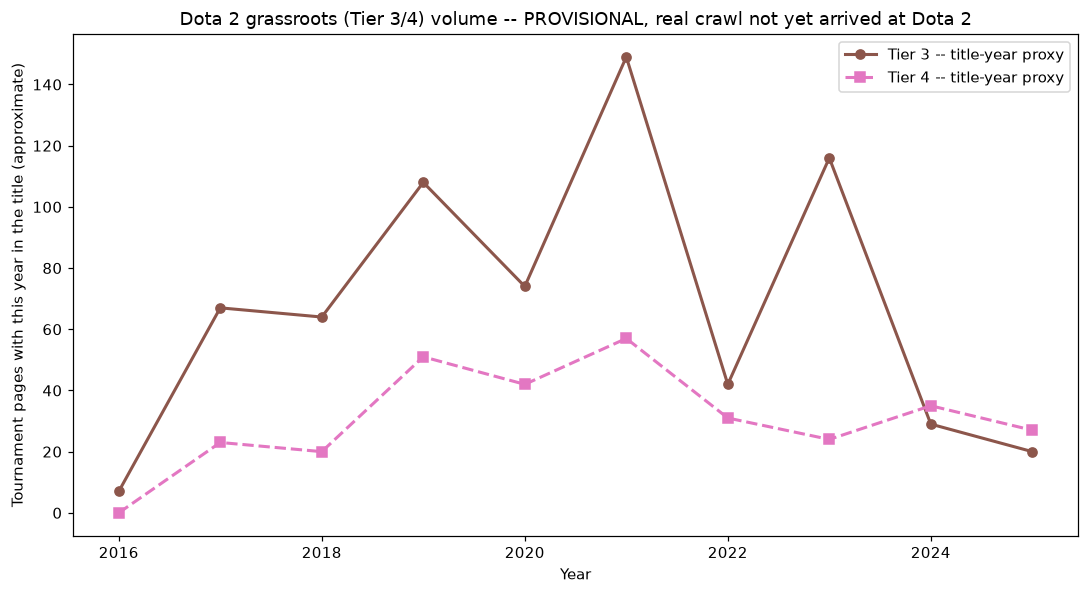

  yr  tier3  tier4
2016      7      0
2017     67     23
2018     64     20
2019    108     51
2020     74     42
2021    149     57
2022     42     31
2023    116     24
2024     29     35
2025     20     27


In [14]:
bc_df = pd.DataFrame({"yr": sorted(set(t3_years) | set(t4_years))}).assign(
    tier3=lambda d: d["yr"].map(t3_years).fillna(0),
    tier4=lambda d: d["yr"].map(t4_years).fillna(0),
)
bc_df = bc_df[(bc_df["yr"] >= 2016) & (bc_df["yr"] <= 2025)]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(bc_df["yr"], bc_df["tier3"], "o-", color="#8c564b", linewidth=2, label="Tier 3 -- title-year proxy")
ax.plot(bc_df["yr"], bc_df["tier4"], "s--", color="#e377c2", linewidth=2, label="Tier 4 -- title-year proxy")
ax.set_xlabel("Year")
ax.set_ylabel("Tournament pages with this year in the title (approximate)")
ax.set_title("Dota 2 grassroots (Tier 3/4) volume -- PROVISIONAL, real crawl not yet arrived at Dota 2")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig9_grassroots_proxy.png", dpi=110)
plt.show()

print(bc_df.to_string(index=False))

## 12. Logistic (S-curve) fit

Same honesty standard as the CS notebook §9: report the fit's own
uncertainty, don't force a headline number the data doesn't support.

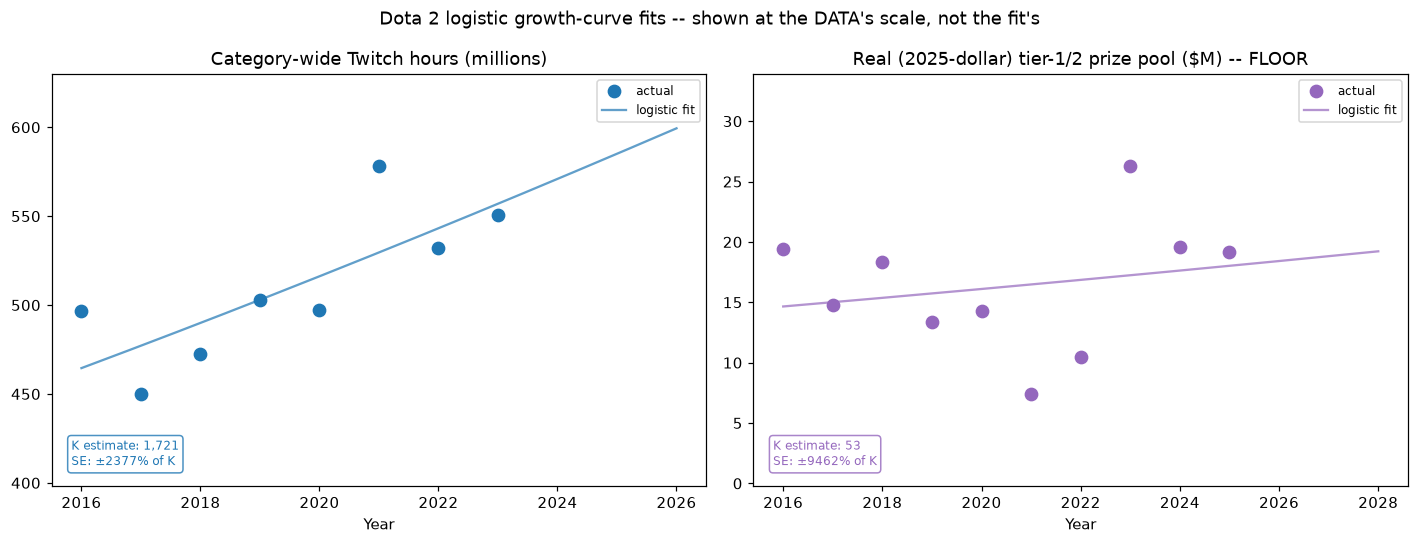

Category-wide hours (M): estimated K=1,720.8 (SE ±40,907.8, 2377% of K) -- current value is 32% of estimated K
Real prize pool ($M, 2025, FLOOR): estimated K=53.0 (SE ±5,016.3, 9462% of K) -- current value is 36% of estimated K


In [15]:
def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

def fit_and_plot(df, y_col, label, color, ax):
    t = df["yr"].values.astype(float)
    y = df[y_col].values.astype(float)
    t0_guess = t.mean()
    K_guess = y.max() * 1.3
    ax.plot(t, y, "o", color=color, markersize=8, label="actual")
    try:
        popt, pcov = curve_fit(
            logistic, t, y, p0=[K_guess, 0.3, t0_guess],
            maxfev=20000, bounds=([y.max(), 0.001, t.min() - 20], [y.max() * 10, 5, t.max() + 20]),
        )
        K, r, t0 = popt
        K_se = np.sqrt(pcov[0, 0]) if np.isfinite(pcov[0, 0]) else np.nan
        t_fit = np.linspace(t.min(), t.max() + 3, 200)
        y_fit = logistic(t_fit, *popt)
        ax.plot(t_fit, y_fit, "-", color=color, alpha=0.7, linewidth=1.5, label="logistic fit")
        y_pad = (y.max() - y.min()) * 0.4 or y.max() * 0.2
        ax.set_ylim(min(y.min(), y_fit.min()) - y_pad, y.max() + y_pad)
        current_value = y[-1]
        pct_of_K = 100 * current_value / K if K else np.nan
        se_pct = 100 * K_se / K if K else np.nan
        ax.text(0.03, 0.05, f"K estimate: {K:,.0f}\nSE: \u00b1{se_pct:.0f}% of K",
                transform=ax.transAxes, fontsize=8, color=color,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor=color))
        return {"label": label, "K": K, "K_se": K_se, "current": current_value, "pct_of_K": pct_of_K}
    except RuntimeError as e:
        print(f"{label}: fit did not converge ({e})")
        return None

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hours_df = dota2_hours[dota2_hours["complete"]].copy()
hours_df["y"] = hours_df["hours"] / 1e6
res1 = fit_and_plot(hours_df, "y", "Category-wide hours (M)", "#1f77b4", axes[0])
axes[0].set_title("Category-wide Twitch hours (millions)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)

prize_df = infra[(infra["yr"] >= 2016) & (infra["yr"] <= COMPLETE_THROUGH)].copy()
prize_df["y"] = prize_df["prize_pool_real_2025"] / 1e6
res2 = fit_and_plot(prize_df, "y", "Real prize pool ($M, 2025, FLOOR)", "#9467bd", axes[1])
axes[1].set_title("Real (2025-dollar) tier-1/2 prize pool ($M) -- FLOOR")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)

fig.suptitle("Dota 2 logistic growth-curve fits -- shown at the DATA's scale, not the fit's")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig10_scurve.png", dpi=110)
plt.show()

for res in [res1, res2]:
    if res:
        se_pct = 100 * res["K_se"] / res["K"] if res["K"] else float("nan")
        print(f"{res['label']}: estimated K={res['K']:,.1f} (SE \u00b1{res['K_se']:,.1f}, {se_pct:.0f}% of K) -- "
              f"current value is {res['pct_of_K']:.0f}% of estimated K")

## 13. Dota 2 in context — against the whole Twitch platform and where esports growth went

Same replication as the CS notebook §16, `NAME_TO_TITLE_ID`-mapped from
the raw Kaggle CSV directly (not copy-pasted from any other notebook).

In [16]:
from collectors.kaggle_import import NAME_TO_TITLE_ID

KAGGLE_CSV = REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv"
raw = pd.read_csv(KAGGLE_CSV, encoding="cp1252")
raw.columns = [c.strip() for c in raw.columns]
raw["year_month"] = raw["Year"].astype(str).str.zfill(4) + "-" + raw["Month"].astype(str).str.zfill(2)
raw["title_id"] = raw["Game"].str.strip().str.lower().map(NAME_TO_TITLE_ID)

matched = raw.dropna(subset=["title_id"]).copy()
title_monthly = matched.groupby(["title_id", "year_month"], as_index=False)["Hours_watched"].sum()

BASELINE_START, BASELINE_END = "2016-01", "2016-12"
RECENT_START, RECENT_END = "2023-10", "2024-09"
baseline_by_title = title_monthly[title_monthly["year_month"].between(BASELINE_START, BASELINE_END)].groupby("title_id")["Hours_watched"].sum()
matched_ids = sorted(title_monthly["title_id"].unique())
margin_check = pd.DataFrame({"hours_2016": baseline_by_title}).reindex(matched_ids).fillna(0)
extensive_ids = margin_check[margin_check["hours_2016"] == 0].index.tolist()

monthly_total = raw.groupby("year_month")["Hours_watched"].sum().rename("total_hours")
esports_monthly = title_monthly.groupby("year_month")["Hours_watched"].sum().rename("esports_hours")
extensive_monthly = title_monthly[title_monthly["title_id"].isin(extensive_ids)].groupby("year_month")["Hours_watched"].sum().rename("extensive_hours")
dota2_monthly = title_monthly[title_monthly["title_id"] == "dota2"].set_index("year_month")["Hours_watched"].rename("dota2_hours")

context_df = pd.concat([monthly_total, esports_monthly, extensive_monthly, dota2_monthly], axis=1).fillna(0)
context_df["month"] = pd.to_datetime(context_df.index + "-01")
context_df = context_df.sort_values("month").reset_index(drop=True)

base = context_df.iloc[0]
for col in ["total_hours", "esports_hours", "extensive_hours", "dota2_hours"]:
    context_df[col + "_idx"] = 100 * context_df[col] / base[col]

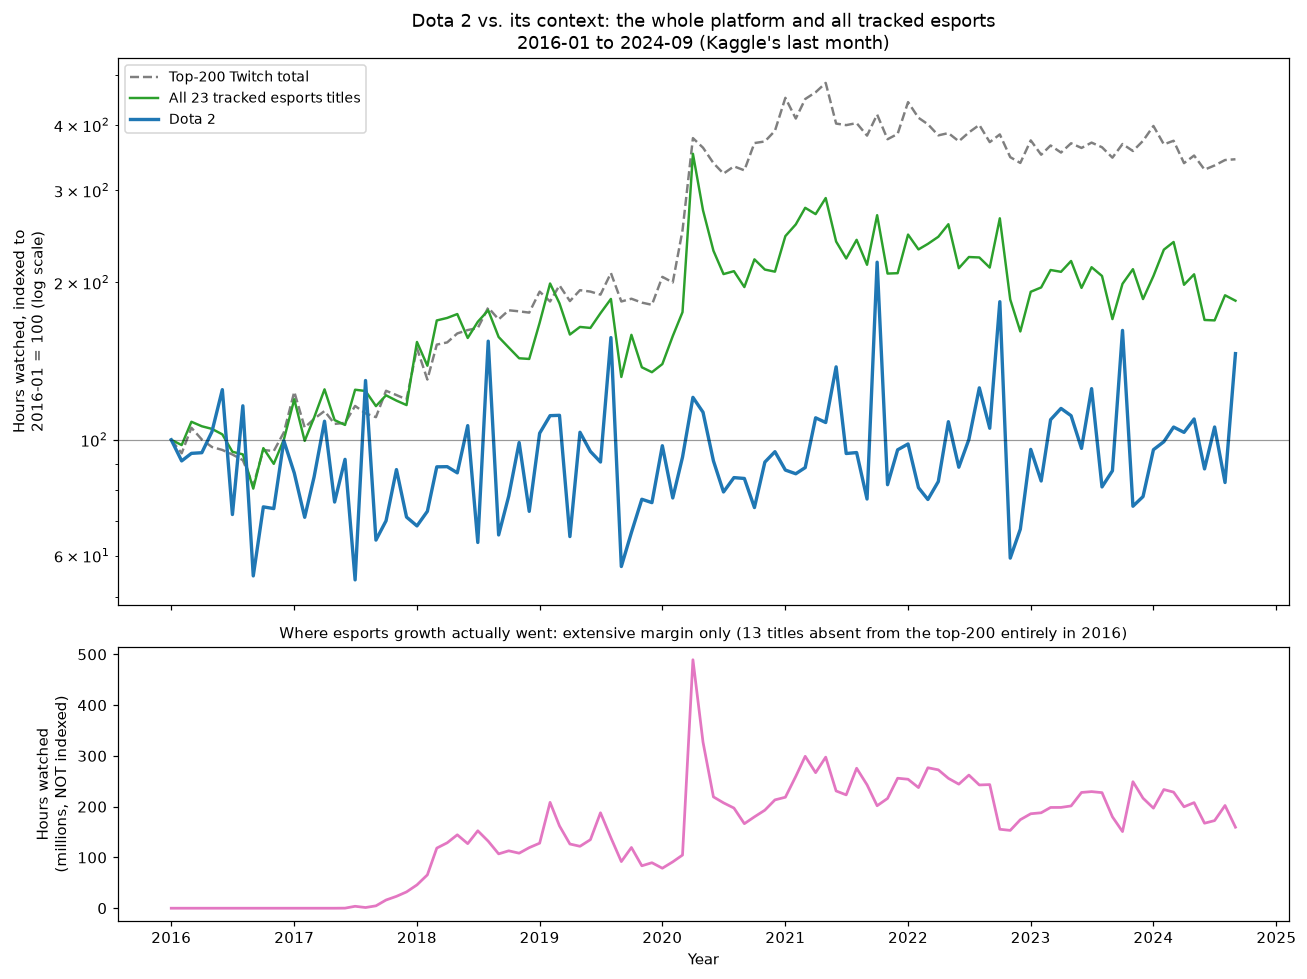

Final index values (2024-09, base=100 at 2016-01, single-month base):
  Top-200 total:            344.2
  All 23 tracked esports:   184.6
  Dota 2:                   146.2


In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), height_ratios=[2, 1], sharex=True)

ax1.plot(context_df["month"], context_df["total_hours_idx"], color="#7f7f7f", linestyle="--", linewidth=1.6, label="Top-200 Twitch total")
ax1.plot(context_df["month"], context_df["esports_hours_idx"], color="#2ca02c", linewidth=1.6, label="All 23 tracked esports titles")
ax1.plot(context_df["month"], context_df["dota2_hours_idx"], color="#1f77b4", linewidth=2.2, label="Dota 2")
ax1.axhline(100, color="black", linewidth=0.8, alpha=0.4)
ax1.set_ylabel("Hours watched, indexed to\n2016-01 = 100 (log scale)")
ax1.set_yscale("log")
ax1.set_title("Dota 2 vs. its context: the whole platform and all tracked esports\n2016-01 to 2024-09 (Kaggle's last month)")
ax1.legend(loc="upper left", fontsize=9)

ax2.plot(context_df["month"], context_df["extensive_hours"] / 1e6, color="#e377c2", linewidth=1.8)
ax2.set_ylabel("Hours watched\n(millions, NOT indexed)")
ax2.set_title(f"Where esports growth actually went: extensive margin only ({len(extensive_ids)} titles absent from the top-200 entirely in 2016)", fontsize=10)
ax2.set_xlabel("Year")

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig11_context.png", dpi=110)
plt.show()

final = context_df.iloc[-1]
print(f"Final index values ({context_df['month'].iloc[-1].strftime('%Y-%m')}, base=100 at 2016-01, single-month base):")
print(f"  Top-200 total:            {final['total_hours_idx']:.1f}")
print(f"  All 23 tracked esports:   {final['esports_hours_idx']:.1f}")
print(f"  Dota 2:                   {final['dota2_hours_idx']:.1f}")

## 14. Bottom line

**Against "finished growing"**: category-wide attention (§2) is the
steadiest of any title looked at in this pair of notebooks — 2023 sits
only 4.8% below the 2021 peak, no sharp crash. Against the platform-wide
context (§13), Dota 2's own index value (146.2) is actually *higher*
than CS's (117.4) on the identical single-month-base measure — Dota 2
has grown more since 2016 than CS has, by this specific metric, even
though both still trail the platform (344.2) and the all-esports
aggregate (184.6) badly.

**Against "still growing" — and more sharply than CS showed**: tournament
count (§3) collapsed by ~80% from its 2017-2018 peak (259) to 2021-2022's
trough (51-53), then surged back past the old peak in 2024-2025
(267/220) — a far more violent swing than CS's tournament-count history.
Organizer-level consolidation (§8) is dramatically more extreme than CS's
own finding: distinct organizers fell from 26 (2016) to just 8 (2021,
2025), with organizer HHI reaching 0.30-0.40 in 2021-2023 — several times
higher than CS's own peak (~0.06). And **once the Saudi-backed lineage is
excluded (§9), the picture changes materially, unlike CS's**: 2016
remains the real-dollar peak even after 2025, meaning Dota 2's
non-state-backed prize economy has *not* recovered to its 2016 level by
2025 — the opposite of CS's finding, where excluding the same lineage
*strengthened* the "still growing" case. Dota 2's own flagship event
(§7) has been Saudi-funded for five straight years running (2022-2026),
something CS's flagship never showed — it reverted to non-lineage
organizers (BLAST, PGL) after 2021.

**The logistic fit (§12) fails the same way it did for CS** — both
series' asymptote estimates carry a standard error far larger than the
estimate itself (2377% and 9462% of K), confirming Dota 2's shape isn't
the smooth, monotonic approach to a ceiling the model assumes either.

**What's still open, not glossed over**: the grassroots (Tier 3/4) proxy
(§11) is provisional — the real crawl hasn't reached Dota 2 yet.
`{{TeamPrizePool}}`'s parsing gap (§0's neighbor finding, `docs/
system_reference.md` §6) means every prize-pool figure here is a floor,
likely understating more for Dota 2 than for CS given the lower coverage
rate. The `detected_costream` metric (§10) has nothing to say yet — zero
Dota 2 tournaments have overlapped this project's short live-collection
window so far.

**Read overall**: less "has Dota 2 finished growing" and more "Dota 2's
organic (non-state-backed) growth looks weaker than CS's once the same
lineage is controlled for, even though its raw attention numbers are
smoother and, on one specific platform-context metric, actually ahead of
CS's." The two titles arrived at superficially similar totals through
very different paths — CS via broad-based, multi-organizer expansion;
Dota 2 via extreme organizer consolidation and increasing reliance on a
small number of enormous, externally-funded events.

## 15. A sharper definition of "finished growing" — are more people watching, or just more content airing?

Raised directly by the user (2026-09-09), applied here to Dota 2 for the
first time (built into `notebooks/cs_growth_trajectory.ipynb` §17
first). `Hours_watched = Avg_viewer_ratio × Hours_streamed` is an exact
identity, not a correlation.

**Corrected in place, same day, after a sharp follow-up question**:
`Avg_viewer_ratio` is an *hours-weighted average of viewers-per-channel*,
not total audience size — it is mechanically driven down by a title
having more simultaneous channels split across the same or a bigger
audience. Checked directly (CS notebook §17a): VALORANT's real total
audience is *larger* than CS's across 2020-2022 and growing ~42% over
that window, while VALORANT's `avg_channels` runs 2.3-4.9x higher than
CS's — a much bigger audience, spread far more thinly, not a weaker one.
The original claim that "VALORANT shows the same pattern as Dota 2" on
this metric compared incomparable things and is retracted (full
derivation: `cs_growth_trajectory.ipynb` §17a). `Avg_viewer_ratio` stays
valid as a *within-one-title* diagnostic — which is what it's used for
below, Dota 2 against CS only, not against VALORANT.

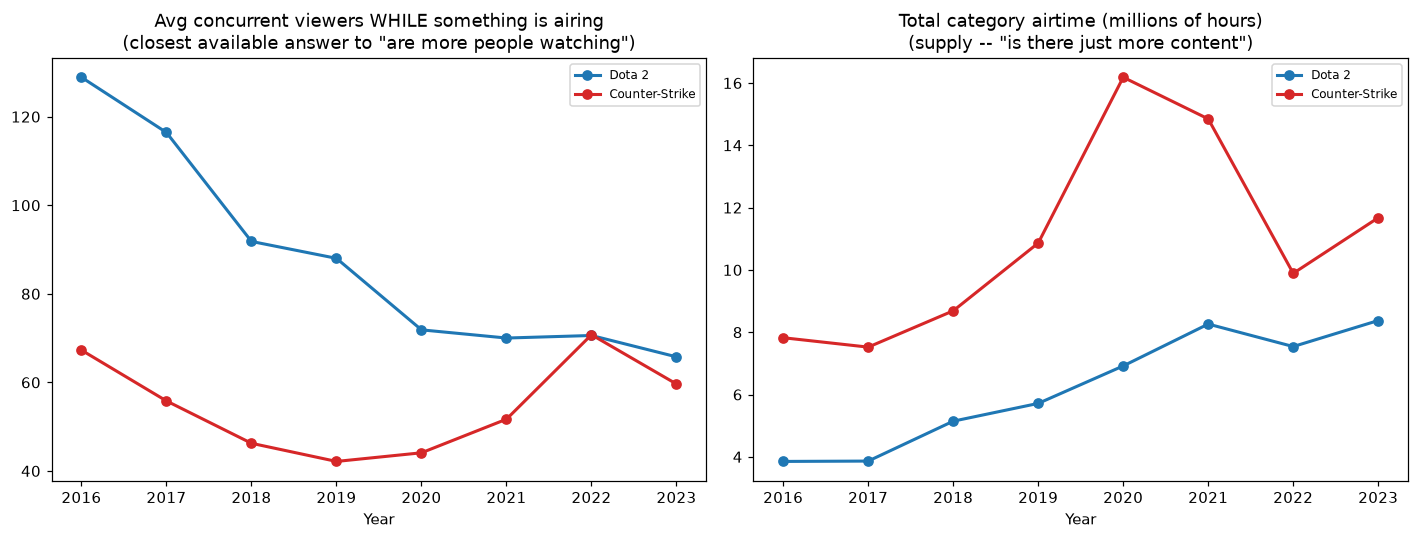

  yr  hours_watched  hours_streamed  avg_viewer_ratio
2016      496585969         3852651             128.9
2017      449879503         3864016             116.4
2018      472414819         5144597              91.8
2019      503022570         5715329              88.0
2020      497151335         6918070              71.9
2021      578484298         8262326              70.0
2022      532253215         7540062              70.6
2023      550839394         8375677              65.8


In [18]:
def viewer_ratio_by_year(title_id: str, through_year: int = 2023) -> pd.DataFrame:
    sub = raw[raw["title_id"] == title_id].groupby("year_month", as_index=False).agg(
        hours_watched=("Hours_watched", "sum"), hours_streamed=("Hours_streamed", "sum"),
    )
    sub["yr"] = sub["year_month"].str[:4].astype(int)
    yearly = sub[sub["yr"] <= through_year].groupby("yr").agg(
        hours_watched=("hours_watched", "sum"), hours_streamed=("hours_streamed", "sum"),
    )
    yearly["avg_viewer_ratio"] = yearly["hours_watched"] / yearly["hours_streamed"]
    return yearly.reset_index()

dota2_ratio = viewer_ratio_by_year("dota2")
cs_ratio_cmp = viewer_ratio_by_year("counter_strike")
# VALORANT deliberately excluded from this specific comparison -- its
# avg_channels is 2.3-4.9x CS's/Dota2's (checked in cs_growth_trajectory.ipynb
# S17a), making avg_viewer_ratio levels incomparable against it. Dota2 vs CS
# is a closer match (both broadcast-centric Classic titles, avg_channels in
# the same hundreds-to-low-thousands range), shown with that caveat still
# explicit, not assumed clean.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for df, label, color in [(dota2_ratio, "Dota 2", "#1f77b4"), (cs_ratio_cmp, "Counter-Strike", "#d62728")]:
    axes[0].plot(df["yr"], df["avg_viewer_ratio"], "o-", color=color, label=label, linewidth=2)
    axes[1].plot(df["yr"], df["hours_streamed"] / 1e6, "o-", color=color, label=label, linewidth=2)

axes[0].set_title("Avg concurrent viewers WHILE something is airing\n(closest available answer to \"are more people watching\")")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)
axes[1].set_title("Total category airtime (millions of hours)\n(supply -- \"is there just more content\")")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_dota2_growth_fig12_viewer_ratio.png", dpi=110)
plt.show()

print(dota2_ratio.round(1).to_string(index=False))

**Read: this is Dota 2's clearest single signal in either notebook, and
it points the same direction as §8's organizer-consolidation finding.**
`Avg_viewer_ratio` declines almost monotonically across the entire
window — 128.9 (2016) to 65.8 (2023), nearly halved — while
`Hours_streamed` more than doubles (3.85M to 8.38M). Total hours watched
(§2) held up only because supply grew enough to offset a shrinking
per-airing audience; on this test, that's the opposite of "more people
watching." **Counter-Strike is the outlier** in this pairing: it also
falls 2016-2019, but recovers past its own 2016 level by 2022, something
Dota 2 doesn't do over the same years.

**Applying the user's proposed definition, narrowed to what this metric
can actually support (within-title, not cross-title against VALORANT)**:
"finished growing" (audience-wise) means `Avg_viewer_ratio` has
plateaued or declined with no recovery. By that test, **Dota 2 shows a
clearer, more sustained audience-depth decline than CS does** — a
genuine reordering relative to the raw prize-pool comparison (§9, §11),
where Dota 2's real-dollar total also looked comparatively weaker once
the Saudi-backed lineage was excluded. Both the money-based and this
narrower audience-based test point the same direction for Dota 2 versus
CS specifically: weaker, not just differently funded. Whether Dota 2 is
weaker than VALORANT on audience terms needs the cross-title-valid
metric instead (`Hours_watched`, §2) — not attempted here since that
comparison wasn't this section's original claim to begin with.

**See also**: `cs_growth_trajectory.ipynb` §18 — the distinct-streamer-
count comparison across Classic vs. Second Coming titles, which found
Dota 2 has the *smallest* creator population of six titles compared
(336K-643K monthly streamers, versus CS's 1.1-1.85M and VALORANT's
2.3-4.8M) — a structural, creator-side signal consistent with this
section's audience-side finding, not duplicated here.